# Práctica: Graph Machine Learning y Graph Neural Networks (GNNs)
Este notebook contiene ejercicios prácticos divididos en dos partes. La primera aborda el Graph ML clásico utilizando `Node2Vec` y métodos de reducción de dimensionalidad. La segunda parte introduce las Graph Neural Networks (GNNs) usando PyTorch Geometric, entrenando una red GCN y resolviendo un ejercicio con GAT.

In [1]:
# Instalación de dependencias necesarias
!pip install networkx node2vec scikit-learn matplotlib
!pip install torch torchvision torchaudio
!pip install torch_geometric

Importamos todas las librerías que vamos a usar para los ejemplos.

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from node2vec import Node2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv

from tqdm import tqdm

## Parte 1: Graph ML Clásico con Node2Vec
Vamos a cargar el dataset **Karate Club**. La tarea consiste en clasificar a qué facción pertenece cada individuo del club de karate basándonos únicamente en sus conexiones.

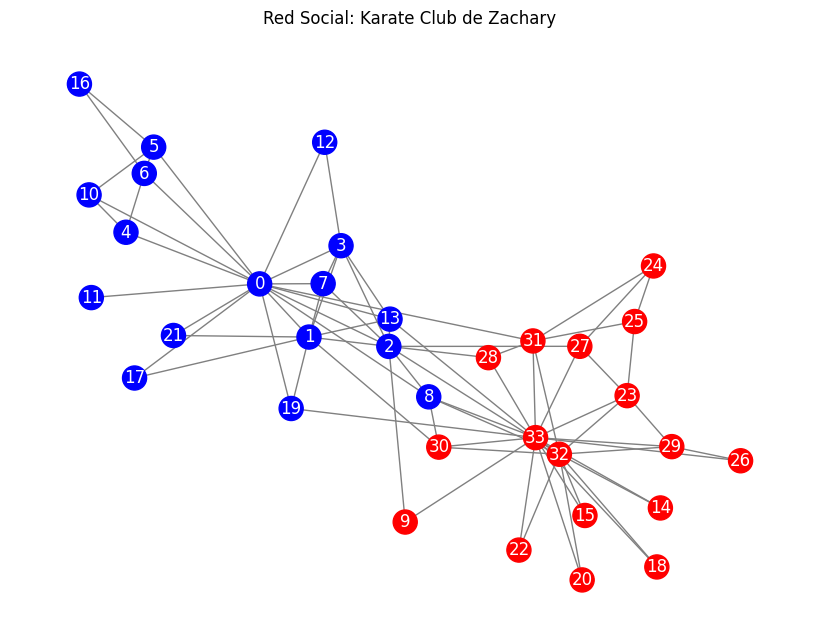

In [3]:
# Cargar la red social
G = nx.karate_club_graph()

# Extraer las etiquetas de las clases (Officer = 1, Mr. Hi = 0)
labels = [1 if G.nodes[i]['club'] == 'Officer' else 0 for i in G.nodes()]

# Visualización de la red original
plt.figure(figsize=(8, 6))
colors = ['red' if label == 1 else 'blue' for label in labels]
nx.draw(G, with_labels=True, node_color=colors, edge_color='gray', font_color='white')
plt.title("Red Social: Karate Club de Zachary")
plt.show()

### Análisis Exploratorio del Grafo (Karate Club)
Antes de aplicar algoritmos de Machine Learning, es fundamental comprender las propiedades topológicas de nuestra red. Calcularemos métricas básicas como el número de nodos, aristas, la densidad del grafo (qué tan conectada está la red respecto al máximo posible) y visualizaremos la distribución de grados (cuántas conexiones tiene cada nodo).

In [4]:
# --- Características del Dataset Karate Club ---
print("--- Características del Dataset Karate Club ---")
print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de aristas: {G.number_of_edges()}")
print(f"¿Grafo dirigido?: {nx.is_directed(G)}")

--- Características del Dataset Karate Club ---
Número de nodos: 34
Número de aristas: 78
¿Grafo dirigido?: False


Grado promedio: 4.59
Densidad de la red: 0.1390
Componentes conectadas: 1


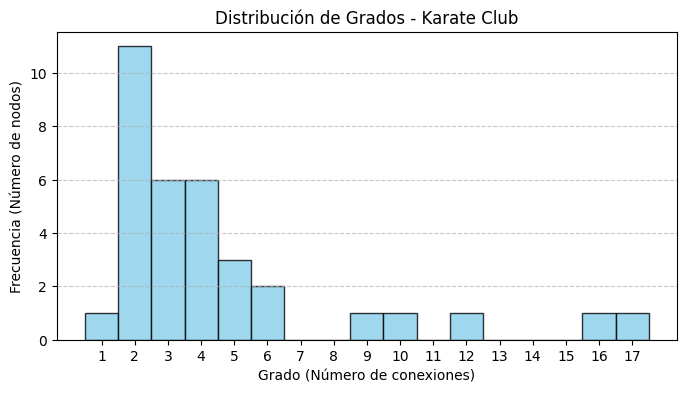

In [5]:
# Extraer los grados de todos los nodos
degrees = [degree for node, degree in G.degree()]
avg_degree = sum(degrees) / G.number_of_nodes()

print(f"Grado promedio: {avg_degree:.2f}")
print(f"Densidad de la red: {nx.density(G):.4f}")
print(f"Componentes conectadas: {nx.number_connected_components(G)}")

# Visualización de la distribución de grados
plt.figure(figsize=(8, 4))
plt.hist(degrees, bins=np.arange(min(degrees), max(degrees) + 2) - 0.5, 
         color='skyblue', edgecolor='black', alpha=0.8)
plt.title("Distribución de Grados - Karate Club")
plt.xlabel("Grado (Número de conexiones)")
plt.ylabel("Frecuencia (Número de nodos)")
plt.xticks(range(min(degrees), max(degrees) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Extracción de características (Embeddings) con Node2Vec
Node2Vec realiza caminos aleatorios (random walks) en el grafo para capturar la topología. Estas caminatas actúan como "frases" que se le pasan a un modelo similar a Word2Vec para obtener una representación vectorial continua de cada nodo. Podemos probar diferentes hiperparámetros y ver las diferencias.

In [6]:
# 1. Generar caminos y entrenar Node2Vec
node2vec = Node2Vec(G, dimensions=4, walk_length=5, num_walks=10, workers=1, quiet=True)
model_n2v = node2vec.fit(window=10, min_count=1, batch_words=4)

In [7]:
# 2. Extraer los embeddings de todos los nodos
embeddings_n2v = [model_n2v.wv[str(i)] for i in range(len(G.nodes()))]

# 3. Entrenar un clasificador simple (Regresión Logística)
X_train, X_test, y_train, y_test = train_test_split(embeddings_n2v, labels, test_size=0.3, random_state=42)
clf_n2v = LogisticRegression().fit(X_train, y_train)
acc_n2v = accuracy_score(y_test, clf_n2v.predict(X_test))

print(f"Accuracy de Node2Vec + Regresión Logística: {acc_n2v:.4f}")

Accuracy de Node2Vec + Regresión Logística: 0.2727


### Visualización: Ground Truth vs Predicciones de Node2Vec
A continuación, comparamos las etiquetas reales del Karate Club con las predicciones hechas por Node2Vec. Para que la comparación sea visualmente clara, utilizaremos la misma disposición de nodos (`spring_layout`) en ambos gráficos y resaltaremos con un borde amarillo aquellos nodos que el modelo ha clasificado incorrectamente.

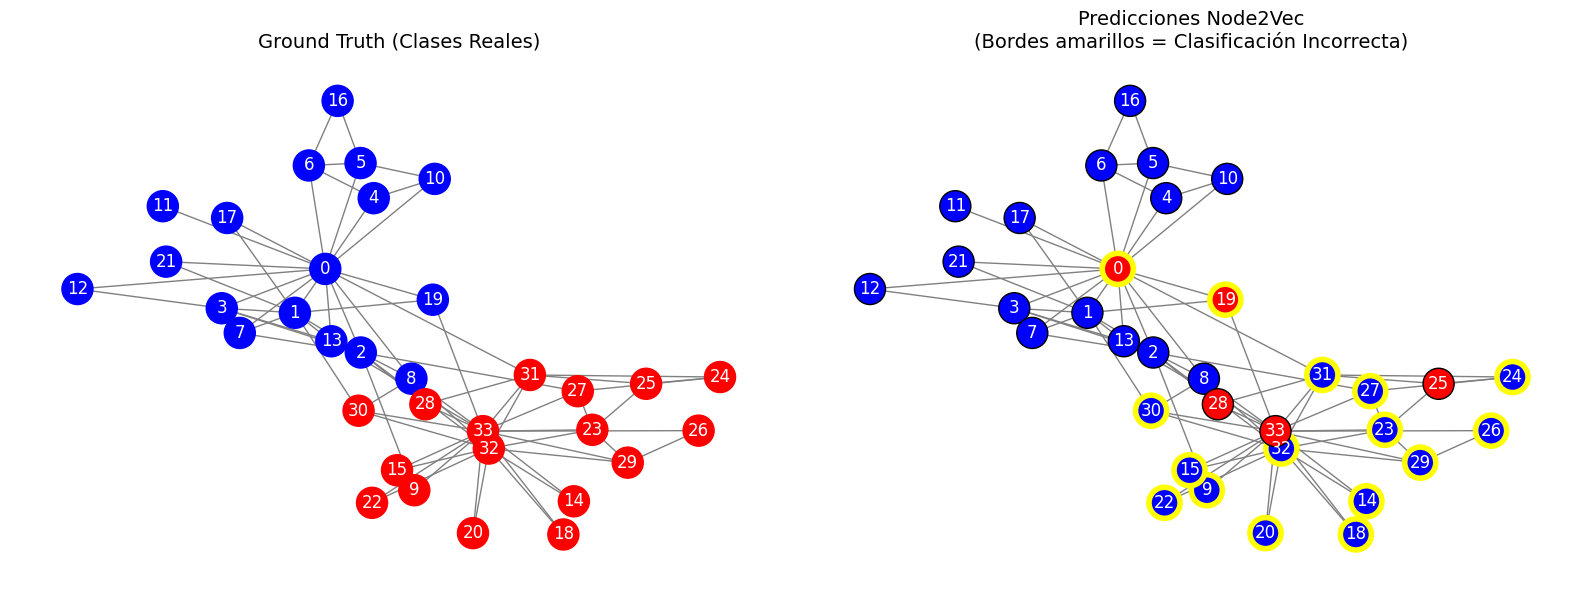

Número total de errores en el grafo completo: 16 de 34 nodos.


In [8]:
# 1. Hacer predicciones para todos los nodos del grafo
predicted_labels = clf_n2v.predict(embeddings_n2v)

# 2. Identificar qué nodos fueron clasificados correctamente y cuáles no
correct_predictions = (predicted_labels == labels)

# 3. Configurar la visualización lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calcular una posición fija (layout) para que ambos grafos se vean con la misma estructura
pos = nx.spring_layout(G, seed=42)

# Colores (Rojo = Officer, Azul = Mr. Hi)
colors_true = ['red' if label == 1 else 'blue' for label in labels]
colors_pred = ['red' if label == 1 else 'blue' for label in predicted_labels]

# --- Subgráfico 1: Ground Truth ---
nx.draw(G, pos, ax=axes[0], with_labels=True, node_color=colors_true, 
        edge_color='gray', font_color='white', node_size=500)
axes[0].set_title("Ground Truth (Clases Reales)", fontsize=14)

# --- Subgráfico 2: Predicciones de Node2Vec ---
# Los nodos incorrectos tendrán un borde amarillo grueso para localizarlos fácilmente
node_borders = ['black' if correct else 'yellow' for correct in correct_predictions]
line_widths = [1 if correct else 4 for correct in correct_predictions]

nx.draw(G, pos, ax=axes[1], with_labels=True, node_color=colors_pred, 
        edge_color='gray', font_color='white', node_size=500,
        edgecolors=node_borders, linewidths=line_widths)
axes[1].set_title("Predicciones Node2Vec\n(Bordes amarillos = Clasificación Incorrecta)", fontsize=14)

plt.tight_layout()
plt.show()

# Imprimir resumen de errores
num_errors = len(correct_predictions) - sum(correct_predictions)
print(f"Número total de errores en el grafo completo: {num_errors} de {len(labels)} nodos.")

### Ejercicio 1: Comparación con otros algoritmos de Graph Machine Learning.
**Tarea:** Utiliza otro algoritmo de Graph Machine Learning básico (no GNNs ni Graph Transformers) para entrenar en el mismo dataset del Club de Karate en la misma tarea 

Justifica la elección del algoritmo, ya sea por el tipo de problema que estamos resolviendo, velocidad de entrenamiento o rendimiento. 

Compara los resultados entre Node2Vec y este otro algoritmo. Usa las métricas de evaluación que consideres necesarias (accuracy, velocidad de entrenamiento, otras métricas, ...).

Compara los resultados con imágenes, ya sea del proceso de entrenamiento (comparativa de las funciones de coste, diferencias en la evaluación de los modelos durante el entrenamiento) o de la evaluación final de cada nodo.

--- Comparación test (misma semilla train_test_split=42) ---
Node2Vec      — acc=0.3636  P=0.3333  R=0.1667  F1=0.2222
Espectral     — acc=0.9091  P=0.8571  R=1.0000  F1=0.9231
Tiempo embed+fit LR — Node2Vec: 0.0692s | Espectral (solo embed+fit): 0.0008s


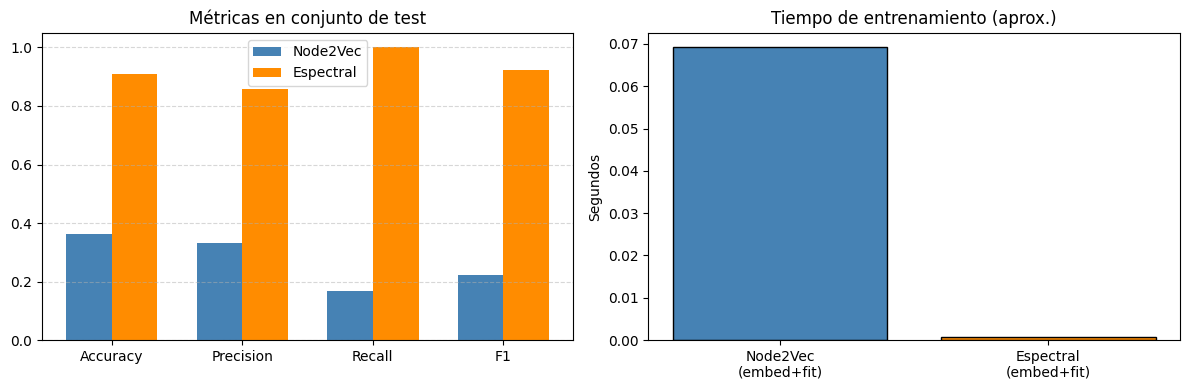

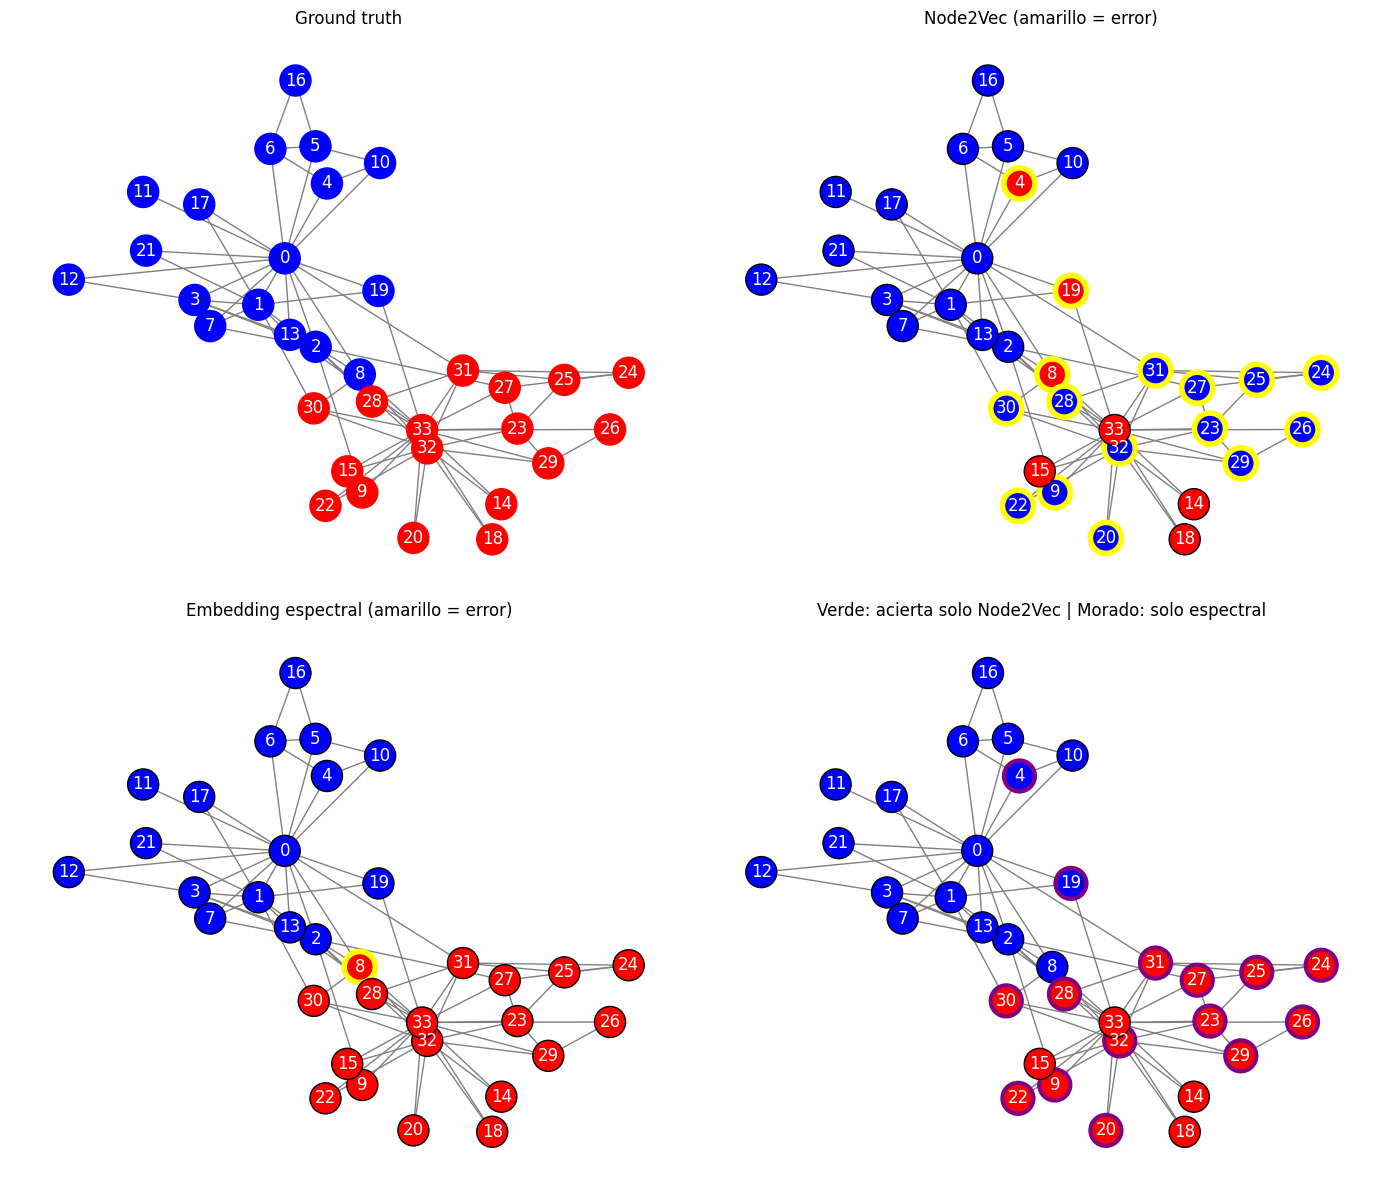

Errores globales — Node2Vec: 16 | Espectral: 1


In [9]:
import time
from sklearn.metrics import precision_score, recall_score, f1_score

# Etiquetas alineadas con orden de nodos 0..n-1
nodes_order = sorted(G.nodes())
y_karate = [1 if G.nodes[i]["club"] == "Officer" else 0 for i in nodes_order]


def spectral_embedding(G, dimensions=4):
    """Embeddings espectrales: autovectores del Laplaciano normalizado (sin GNN ni random walks)."""
    A = nx.to_numpy_array(G, nodelist=nodes_order)
    deg = A.sum(axis=1).astype(float)
    d_inv_sqrt = np.zeros_like(deg)
    mask = deg > 0
    d_inv_sqrt[mask] = np.power(deg[mask], -0.5)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    L_sym = np.eye(len(G)) - D_inv_sqrt @ A @ D_inv_sqrt
    w, V = np.linalg.eigh(L_sym)
    # Saltamos el autovector trivial (constante); tomamos los siguientes `dimensions`
    return V[:, 1 : dimensions + 1]


# --- Tiempo y entrenamiento: embedding espectral + Regresión Logística ---
t0 = time.perf_counter()
X_spec = spectral_embedding(G, dimensions=4)
t_train_spec = time.perf_counter() - t0

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_spec, y_karate, test_size=0.3, random_state=42
)
clf_spec = LogisticRegression(max_iter=2000).fit(X_tr_s, y_tr_s)
y_pred_spec_te = clf_spec.predict(X_te_s)
acc_spec = accuracy_score(y_te_s, y_pred_spec_te)
prec_spec = precision_score(y_te_s, y_pred_spec_te, zero_division=0)
rec_spec = recall_score(y_te_s, y_pred_spec_te, zero_division=0)
f1_spec = f1_score(y_te_s, y_pred_spec_te, zero_division=0)

# --- Misma partición con Node2Vec (re-entrenar para medir tiempo de forma comparable) ---
t0 = time.perf_counter()
n2v_cmp = Node2Vec(G, dimensions=4, walk_length=5, num_walks=10, workers=1, quiet=True)
model_n2v_cmp = n2v_cmp.fit(window=10, min_count=1, batch_words=4)
t_train_n2v = time.perf_counter() - t0
emb_n2v = [model_n2v_cmp.wv[str(i)] for i in nodes_order]

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    emb_n2v, y_karate, test_size=0.3, random_state=42
)
clf_n2v_cmp = LogisticRegression(max_iter=2000).fit(X_tr_n, y_tr_n)
y_pred_n2v_te = clf_n2v_cmp.predict(X_te_n)
acc_n2v_cmp = accuracy_score(y_te_n, y_pred_n2v_te)
prec_n2v = precision_score(y_te_n, y_pred_n2v_te, zero_division=0)
rec_n2v = recall_score(y_te_n, y_pred_n2v_te, zero_division=0)
f1_n2v = f1_score(y_te_n, y_pred_n2v_te, zero_division=0)

print("--- Comparación test (misma semilla train_test_split=42) ---")
print(f"Node2Vec      — acc={acc_n2v_cmp:.4f}  P={prec_n2v:.4f}  R={rec_n2v:.4f}  F1={f1_n2v:.4f}")
print(f"Espectral     — acc={acc_spec:.4f}  P={prec_spec:.4f}  R={rec_spec:.4f}  F1={f1_spec:.4f}")
print(f"Tiempo embed+fit LR — Node2Vec: {t_train_n2v:.4f}s | Espectral (solo embed+fit): {t_train_spec:.4f}s")

# Gráfico de métricas y tiempos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics_names))
w = 0.35
axes[0].bar(x - w / 2, [acc_n2v_cmp, prec_n2v, rec_n2v, f1_n2v], w, label="Node2Vec", color="steelblue")
axes[0].bar(x + w / 2, [acc_spec, prec_spec, rec_spec, f1_spec], w, label="Espectral", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Métricas en conjunto de test")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

axes[1].bar(["Node2Vec\n(embed+fit)", "Espectral\n(embed+fit)"], [t_train_n2v, t_train_spec], color=["steelblue", "darkorange"], edgecolor="black")
axes[1].set_ylabel("Segundos")
axes[1].set_title("Tiempo de entrenamiento (aprox.)")
plt.tight_layout()
plt.show()

# Predicciones en todos los nodos para visualización tipo ground truth
pred_spec_all = clf_spec.predict(X_spec)
pos = nx.spring_layout(G, seed=42)
correct_spec = pred_spec_all == np.array(y_karate)
correct_n2v_all = clf_n2v_cmp.predict(emb_n2v) == np.array(y_karate)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
colors_true = ["red" if c == 1 else "blue" for c in y_karate]
colors_spec = ["red" if c == 1 else "blue" for c in pred_spec_all]
colors_n2v = ["red" if c == 1 else "blue" for c in clf_n2v_cmp.predict(emb_n2v)]

nx.draw(G, pos, ax=axes[0, 0], with_labels=True, node_color=colors_true, edge_color="gray", font_color="white", node_size=500)
axes[0, 0].set_title("Ground truth")

nx.draw(
    G, pos, ax=axes[0, 1], with_labels=True, node_color=colors_n2v,
    edge_color="gray", font_color="white", node_size=500,
    edgecolors=["black" if c else "yellow" for c in correct_n2v_all],
    linewidths=[1 if c else 4 for c in correct_n2v_all],
)
axes[0, 1].set_title("Node2Vec (amarillo = error)")

nx.draw(
    G, pos, ax=axes[1, 0], with_labels=True, node_color=colors_spec,
    edge_color="gray", font_color="white", node_size=500,
    edgecolors=["black" if c else "yellow" for c in correct_spec],
    linewidths=[1 if c else 4 for c in correct_spec],
)
axes[1, 0].set_title("Embedding espectral (amarillo = error)")

# Diferencia de aciertos entre métodos (opcional)
diff = np.array(correct_n2v_all, dtype=int) - np.array(correct_spec, dtype=int)
node_edge = []
lw = []
for d in diff:
    if d == 0:
        node_edge.append("black")
        lw.append(1)
    else:
        node_edge.append("green" if d > 0 else "purple")
        lw.append(3)
nx.draw(G, pos, ax=axes[1, 1], with_labels=True, node_color=colors_true, edge_color="gray", font_color="white", node_size=500, edgecolors=node_edge, linewidths=lw)
axes[1, 1].set_title("Verde: acierta solo Node2Vec | Morado: solo espectral")

plt.tight_layout()
plt.show()
print(f"Errores globales — Node2Vec: {len(y_karate) - sum(correct_n2v_all)} | Espectral: {len(y_karate) - sum(correct_spec)}")

**Justificación:** Se eligió el **embedding espectral** (autovectores del Laplaciano normalizado del grafo) porque es un método clásico de *Graph ML* distinto de Node2Vec: no usa *random walks* ni modelos tipo Word2Vec, sino el espectro del grafo (estructura global de conectividad y “suavidad” de señales sobre la red). Es **muy rápido** en grafos pequeños como Karate Club (una descomposición en valores propios frente a muestrear muchos paseos y entrenar embeddings neuronales), lo que lo hace atractivo cuando el grafo cabe en memoria y se busca una línea base interpretable. En cuanto al rendimiento, en grafos tan pequeños ambos enfoques pueden alternar ventajas según la partición train/test; por eso se reportan **accuracy, precision, recall y F1**, además del **tiempo** y mapas de errores por nodo.

## Parte 2: Redes Neuronales de Grafos (GNNs)
Para esta sección, usaremos **PyTorch Geometric (PyG)**. Cargaremos el dataset **Cora**, una red de citaciones académicas (donde las conexiones representan la influencia social y de investigación). El objetivo es clasificar de qué tema trata cada artículo (nodo) en un entorno de aprendizaje semi-supervisado.

Primero, implementaremos una **Graph Convolutional Network (GCN)**. La ecuación de propagación de una GCN estándar es:
$$H^{(l+1)} = \sigma(\tilde{D}^{-\frac{1}{2}}\tilde{A}\tilde{D}^{-\frac{1}{2}}H^{(l)}W^{(l)})$$

In [10]:
# Cargar el dataset Cora
dataset = Planetoid(root='data/Cora', name='Cora')
data = dataset[0]

print(f'Nodos: {data.num_nodes}, Aristas: {data.num_edges}, Features: {dataset.num_node_features}, Clases: {dataset.num_classes}')

Nodos: 2708, Aristas: 10556, Features: 1433, Clases: 7


Processing...
Done!


### Análisis Exploratorio del Dataset (Cora)
Cora es un dataset mucho más grande y complejo, típico en redes neuronales de grafos. Además de la estructura del grafo, cada nodo tiene un vector de características (features) que en este caso representa un modelo Bag-of-Words de las palabras del documento. Vamos a inspeccionar si el grafo es dirigido, si contiene nodos desconectados (aislados) y cómo se distribuyen las clases (temas de los artículos).

In [11]:
print("--- Características del Dataset Cora ---")
print(f"Número de nodos: {data.num_nodes}")
print(f"Número de aristas: {data.num_edges}")
print(f"¿Grafo dirigido?: {data.is_directed()}")
print(f"¿Tiene nodos aislados?: {data.has_isolated_nodes()}")
print(f"¿Tiene auto-bucles (self-loops)?: {data.has_self_loops()}")
print(f"Número de características por nodo: {dataset.num_node_features}")
print(f"Número de clases a predecir: {dataset.num_classes}")

--- Características del Dataset Cora ---
Número de nodos: 2708
Número de aristas: 10556
¿Grafo dirigido?: False
¿Tiene nodos aislados?: False
¿Tiene auto-bucles (self-loops)?: False
Número de características por nodo: 1433
Número de clases a predecir: 7


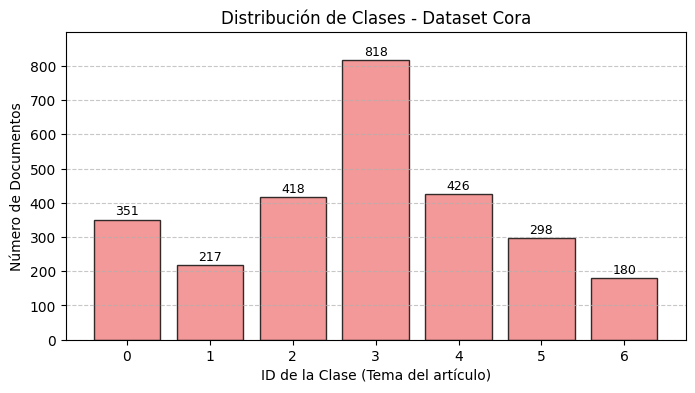

In [12]:
# Distribución de clases
labels = data.y.cpu().numpy()
clases, conteos = np.unique(labels, return_counts=True)

plt.figure(figsize=(8, 4))
bars = plt.bar(clases, conteos, color='lightcoral', edgecolor='black', alpha=0.8)
plt.title("Distribución de Clases - Dataset Cora")
plt.xlabel("ID de la Clase (Tema del artículo)")
plt.ylabel("Número de Documentos")
plt.xticks(clases)

# Añadir el valor sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(conteos) * 1.1) # Dar un poco de espacio para el texto
plt.show()

Definimos la clase del modelo GCN con todos los componentes necesarios y definimos el forward pass del modelo.

In [13]:
# 1. Redefinimos la GCN para que devuelva también los embeddings
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_node_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        
        # Guardamos la representación oculta (embedding)
        embedding = x 
        
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1), embedding

Definimos todos los parámetros necesarios para el entrenamiento. 

In [14]:
# Inicialización
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gcn = GCN().to(device)
data = data.to(device)
optimizer_gcn = torch.optim.Adam(model_gcn.parameters(), lr=0.01, weight_decay=5e-4)

Entrenamos el modelo durante 200 épocas. Guardamos los embeddings cada 20 épocas para ver cómo van cambiando durante el entrenamiento.

In [15]:
# 2. Bucle de Entrenamiento GCN guardando el historial
model_gcn.train()
losses_gcn = []
embeddings_history = {} # Diccionario para guardar los embeddings

print("Entrenando GCN y capturando embeddings...")
for epoch in range(200):
    optimizer_gcn.zero_grad()
    out, emb = model_gcn(data)
    
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_gcn.step()
    losses_gcn.append(loss.item())
    
    # Guardar estado en época 0, cada 20 épocas y en la última (199)
    if epoch == 0 or (epoch + 1) % 20 == 0:
        model_gcn.eval() # Pasar a eval para apagar el dropout y capturar el embedding limpio
        with torch.no_grad():
            _, emb_eval = model_gcn(data)
            embeddings_history[epoch] = emb_eval.cpu().numpy()
        model_gcn.train() # Volver a modo entrenamiento

print("Entrenamiento completado.")

Entrenando GCN y capturando embeddings...


Entrenamiento completado.


Visualizando embeddings:   0%|          | 0/11 [00:00<?, ?it/s]

/opt/miniconda3/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Visualizando embeddings:   9%|▉         | 1/11 [00:05<00:59,  5.91s/it]

Visualizando embeddings:  18%|█▊        | 2/11 [00:12<00:54,  6.10s/it]

Visualizando embeddings:  27%|██▋       | 3/11 [00:18<00:49,  6.17s/it]

...

Visualizando embeddings:  73%|███████▎  | 8/11 [00:48<00:18,  6.10s/it]

Visualizando embeddings:  82%|████████▏ | 9/11 [00:54<00:12,  6.04s/it]

Visualizando embeddings:  91%|█████████ | 10/11 [01:00<00:05,  5.94s/it]

Visualizando embeddings: 100%|██████████| 11/11 [01:05<00:00,  5.90s/it]

Visualizando embeddings: 100%|██████████| 11/11 [01:05<00:00,  6.00s/it]

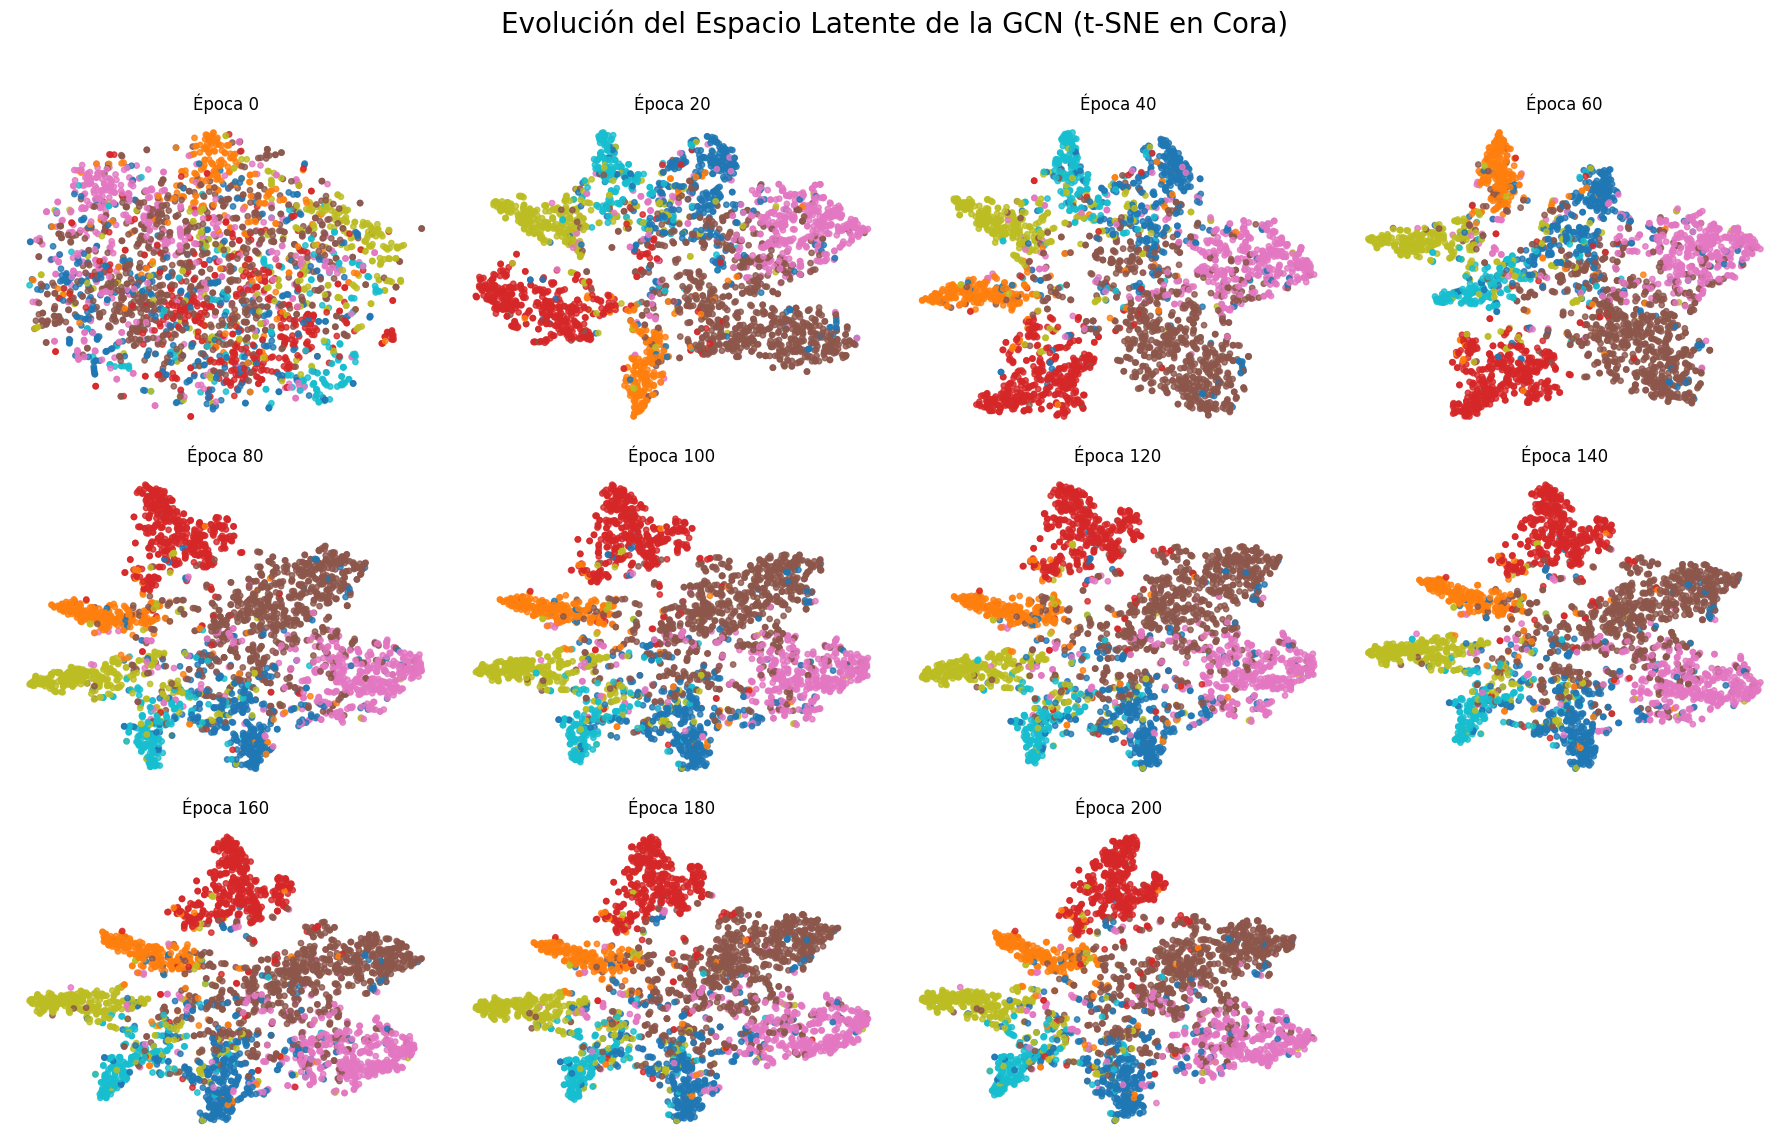

In [16]:
# 3. Visualización de la evolución con t-SNE
# Tenemos 11 momentos guardados (0, 19, 39, ..., 199). Haremos una cuadrícula de 3x4
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

labels_cora = data.y.cpu().numpy()
plot_idx = 0

for epoch, emb in tqdm(embeddings_history.items(), desc="Visualizando embeddings", total=len(embeddings_history)):
    # Aplicar t-SNE para reducir a 2 dimensiones
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    emb_2d = tsne.fit_transform(emb)
    
    # Dibujar
    ax = axes[plot_idx]
    scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels_cora, cmap='tab10', s=15, alpha=0.8)
    ax.set_title(f'Época {epoch + 1 if epoch != 0 else 0}')
    ax.axis('off')
    plot_idx += 1

# Ocultar el último subplot (el número 12) ya que solo tenemos 11 gráficos
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.suptitle('Evolución del Espacio Latente de la GCN (t-SNE en Cora)', fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Evaluamos los resultados del modelo.

In [17]:
# Evaluación Final
model_gcn.eval()
pred_gcn, _ = model_gcn(data)
pred_gcn = pred_gcn.argmax(dim=1)
correct_gcn = (pred_gcn[data.test_mask] == data.y[data.test_mask]).sum()
acc_gcn = int(correct_gcn) / int(data.test_mask.sum())
print(f'Test Accuracy final: {acc_gcn:.4f}')

Test Accuracy final: 0.7960


### Ejercicio 2: Diseño de un algoritmo con GNNs
**Tarea:** Define y entrena un modelo usando otro tipo de GNN u otro algoritmo de Graph Machine Learning más complejo, para el mismo dataset Cora. 

Justifica la elección del algoritmo ya sea por rendimiento, velocidad o por el tipo de problema que estamos resolviendo.

Compara la precisión final y grafica la curva de pérdida (Loss) del entrenamiento de la GNN frente a la de la GCN. Añade otras comparaciones de la gráfica t-SNE de los embeddings durante el entrenamiento de ambos modelos en alguna de las épocas de entrenamiento.

Test accuracy GAT: 0.7880  |  GCN (celda anterior): 0.7960


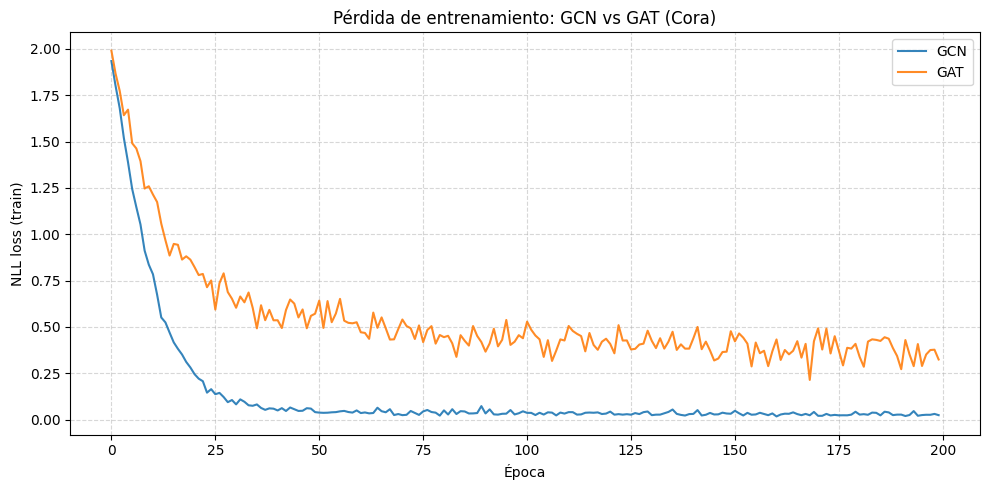

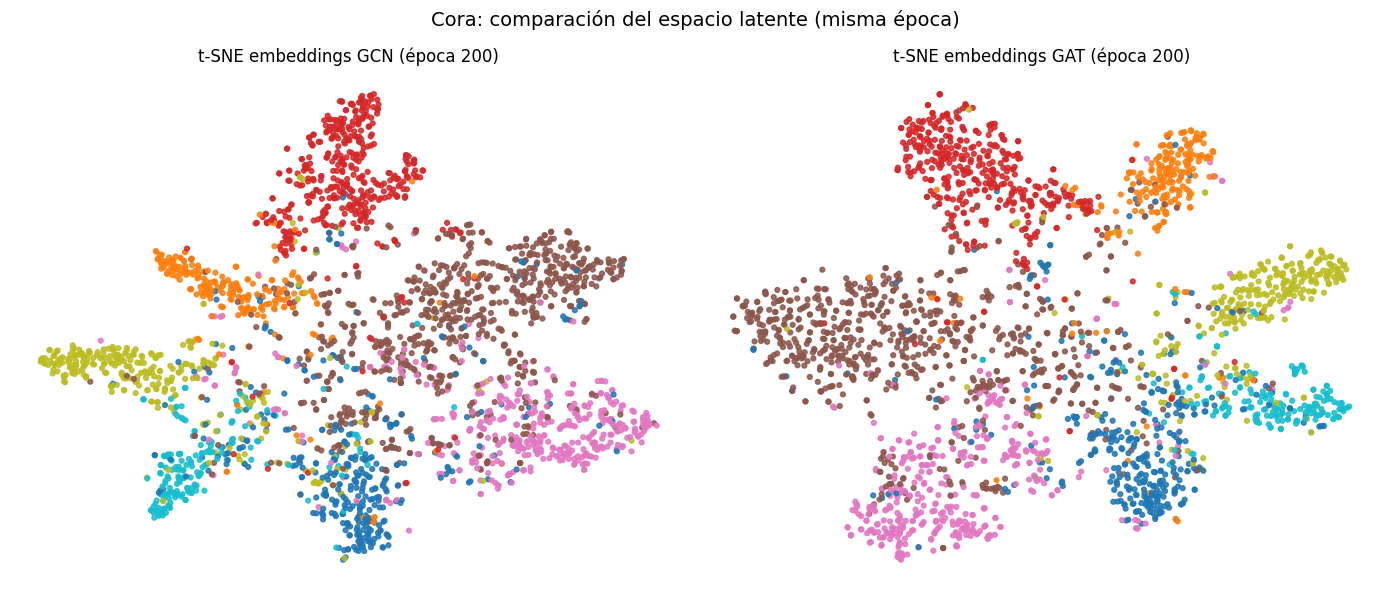

In [18]:
# GAT (Graph Attention Network): atención sobre vecinos — ya importamos GATConv arriba
class GAT(torch.nn.Module):
    def __init__(self, heads=8):
        super().__init__()
        self.conv1 = GATConv(dataset.num_node_features, 8, heads=heads, dropout=0.6)
        self.conv2 = GATConv(8 * heads, dataset.num_classes, heads=1, concat=False, dropout=0.6)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        embedding = x
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1), embedding


data_gat = dataset[0].to(device)
model_gat = GAT(heads=8).to(device)
optimizer_gat = torch.optim.Adam(model_gat.parameters(), lr=0.005, weight_decay=5e-4)

losses_gat = []
embeddings_gat = {}

model_gat.train()
for epoch in range(200):
    optimizer_gat.zero_grad()
    out, emb = model_gat(data_gat)
    loss = F.nll_loss(out[data_gat.train_mask], data_gat.y[data_gat.train_mask])
    loss.backward()
    optimizer_gat.step()
    losses_gat.append(loss.item())

    if epoch == 0 or (epoch + 1) % 20 == 0:
        model_gat.eval()
        with torch.no_grad():
            _, emb_eval = model_gat(data_gat)
            embeddings_gat[epoch] = emb_eval.cpu().numpy()
        model_gat.train()

model_gat.eval()
pred_gat, _ = model_gat(data_gat)
pred_gat = pred_gat.argmax(dim=1)
acc_gat = int((pred_gat[data_gat.test_mask] == data_gat.y[data_gat.test_mask]).sum()) / int(
    data_gat.test_mask.sum()
)
print(f"Test accuracy GAT: {acc_gat:.4f}  |  GCN (celda anterior): {acc_gcn:.4f}")

# Curvas de pérdida
plt.figure(figsize=(10, 5))
plt.plot(losses_gcn, label="GCN", alpha=0.9)
plt.plot(losses_gat, label="GAT", alpha=0.9)
plt.xlabel("Época")
plt.ylabel("NLL loss (train)")
plt.title("Pérdida de entrenamiento: GCN vs GAT (Cora)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# t-SNE: misma época para ambos modelos (última guardada: 199)
epoch_cmp = 199
emb_gcn_tsne = embeddings_history[epoch_cmp]
emb_gat_tsne = embeddings_gat[epoch_cmp]
labels_cora = data_gat.y.cpu().numpy()

tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
z_gcn = tsne.fit_transform(emb_gcn_tsne)
z_gat = tsne.fit_transform(emb_gat_tsne)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(z_gcn[:, 0], z_gcn[:, 1], c=labels_cora, cmap="tab10", s=12, alpha=0.85)
axes[0].set_title(f"t-SNE embeddings GCN (época {epoch_cmp + 1})")
axes[0].axis("off")

axes[1].scatter(z_gat[:, 0], z_gat[:, 1], c=labels_cora, cmap="tab10", s=12, alpha=0.85)
axes[1].set_title(f"t-SNE embeddings GAT (época {epoch_cmp + 1})")
axes[1].axis("off")

plt.suptitle("Cora: comparación del espacio latente (misma época)", fontsize=14)
plt.tight_layout()
plt.show()

**Justificación:** **GAT** pondera a cada vecino con coeficientes de **atención** aprendidos, en lugar de usar solo una agregación fija como en GCN. En Cora es razonable suponer que no todos los vecinos en la red de citas aportan lo mismo al tema del documento; la atención adapta esos pesos por nodo y por capa. El coste es mayor que una GCN “plana”, pero sigue siendo un modelo estándar en PyG y suele **igualar o mejorar** la precisión en clasificación de nodos. La comparación de **curvas de pérdida** muestra la dinámica de optimización; el **t-SNE** en la misma época permite ver si las clases se separan de forma distinta en el espacio latente atendido frente al convolucional.